<table>
<tr>
<td><img src="https://www.institutobme.es/dam/layout/bme-logo.svg" width="150"></td>
<td><table><tr><td><h1>Regresión lineal</h1></td></tr>
           <tr><td><h3>Rafael Caballero Roldán</h3></td></tr></table></td>

</tr>
</table>

### Índice
[Obtención del modelo](#modelo)<br>
[Afinando el error](#error)<br>
[Intervalo de confianza](#intervalo)<br>
[Mejorando el modelo](#mejorando)<br>
[Lasso y Ridge](#lasso)<br>



Antes de empezar comprobamos la versión de sklearn

In [ ]:
import sklearn
sklearn.__version__

Si se quiere actualizar ejecutar el siguiente código (y después Kernel - Restart)

In [ ]:
#!pip  install scikit-learn --upgrade --user

<a name="modelo"></a>
## Obtención del modelo

Empezamos cargando un fichero con las notas de las pruebas PISA. Recordamos la importancia del preprocesado, pero es aquí nos dan ya los datos preparados para que nos centremos en la regresión.

In [ ]:
# Paso 0: Carga y preparación del fichero
import pandas as pd
url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/master/datos/pisaDataClean.csv"
df = pd.read_csv(url)
df

1.- Dividir las columnas en X e y e. Nuestro objetivo será deducir la columna MAT (y) desde dos columnas: SCI y REA, que serán las X

In [ ]:

XColumns = ["SCI", "REA"] # una lista de columnas: las X, las características, las features, las dimensiones...
yColumn = "MAT"  # la y, siempre una única columna
# dividimos en dos; X será un dataframe, y una columna (tipo Series)
X = df[XColumns]
y = df[yColumn]


2.- Dividir las columnas en X e y en train y test. En este caso ponemos 70% para train y 30% para test

In [6]:

from sklearn.model_selection import train_test_split

test = 0.3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= test)

Tendremos que

*   X = X_train + X_test
*   y = y_train + y_test


In [7]:
X

,SCI,REA
0,427.2250,405.2588
1,375.7451,349.8593
2,432.2262,425.3031
3,509.9939,502.9006
4,495.0375,484.8656
...,...,...
58,492.7861,495.5764
59,493.4224,500.1556
60,425.4895,428.3351
61,436.7311,433.5423


In [8]:
X_train

,SCI,REA
23,396.6836,397.5414
47,480.5468,484.7580
60,425.4895,428.3351
42,331.6388,357.7377
51,482.8064,481.4391
39,415.7288,424.9052
48,538.3948,515.9585
28,512.8636,505.2159
44,509.1406,509.1041
22,498.4811,513.1912


In [9]:
X_test

,SCI,REA
4,495.0375,484.8656
59,493.4224,500.1556
2,432.2262,425.3031
58,492.7861,495.5764
16,502.5751,520.8148
40,475.3912,486.8632
54,427.9978,416.2293
17,456.4836,427.1410
43,411.1315,401.2881
12,494.9776,499.3061


3.- Declarar el método y  entrenar con el conjunto train, obteniendo un *modelo*

In [10]:
from sklearn.linear_model import LinearRegression
metodo = LinearRegression()
modelo = metodo.fit(X_train,y_train)

El modelo representa simplemente la recta que mejor ajusta las (X,y) dadas:

In [11]:
modelo.intercept_, modelo.coef_

(np.float64(-40.62455118772937), array([0.91155507, 0.16389638]))

In [12]:
print(f"La recta de regresión es {yColumn} =\
 {round(modelo.coef_[0],3)}*{XColumns[0]} + {round(modelo.coef_[1],3)}*{XColumns[1]} + \
 {modelo.intercept_}")

La recta de regresión es MAT = 0.912*SCI + 0.164*REA +  -40.62455118772937


Aunque veremos que estas predicciones las vamos a hacer automáticamente, podríamos escribir por nuestra cuentra una función que las haga:

In [13]:
def y_predict(X,modelo):
    s = modelo.intercept_
    for i,x in enumerate(X):
        s += x*modelo.coef_[i]
    return s

y_predict([400,450],modelo)

np.float64(397.750850810237)

Vamos a representar gráficamente los datos de entrenamiento y la recta modelo.


```


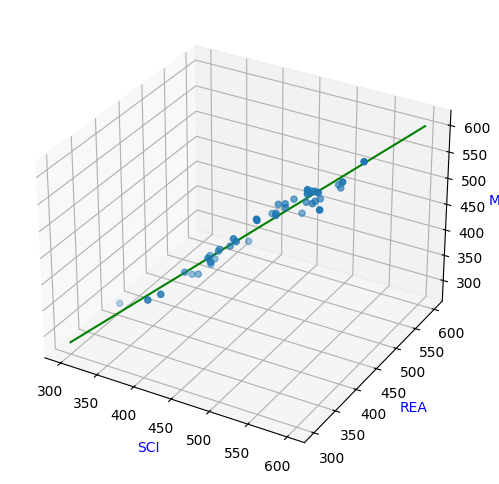

In [14]:
from google.colab import output
output.enable_custom_widget_manager()

#%matplotlib widget

from mpl_toolkits.mplot3d.axes3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib

fig = plt.figure(figsize=(14,6))

# projection='3d' indica que este subplot es en 3d
ax = fig.add_subplot(1, 2, 1, projection='3d')
x = X_train["SCI"]
y = X_train["REA"]
z = y_train
ax.scatter3D( x, y, z)

y_1 = y_predict([300,300],modelo)
y_2 = y_predict([600,600],modelo)
ax.plot3D([300,600],[300,600],[y_1,y_2],color="green")
ax.set_zlabel(r"MAT", fontsize=10, color="blue")
ax.set_xlabel(r"SCI", fontsize=10, color="blue")
ax.set_ylabel(r"REA", fontsize=10, color="blue")
plt.show()

4.- Ahora predecimos con el test y mostramos el error

In [15]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import math
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test,y_pred)
rmse = math.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
print(f"r^2: {round(r2,3)} RMSE: {round(rmse,3)}, MAE:{round(mae,3)}")

r^2: 0.962 RMSE: 7.911, MAE:6.517


Y completamos la figura mostrando los puntos de entrenamiento, de test y la recta

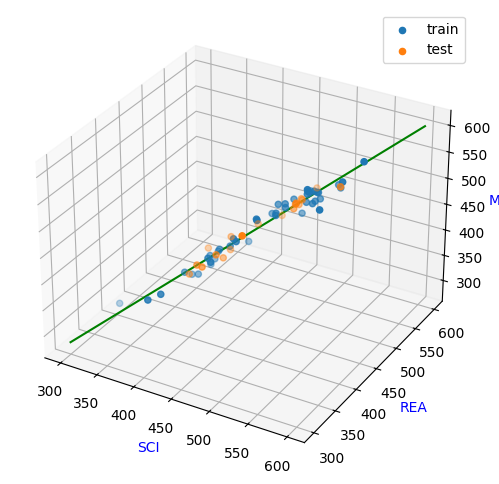

In [16]:
#%matplotlib widget

fig = plt.figure(figsize=(14,6))

# projection='3d' indica que este subplot es en 3d
ax = fig.add_subplot(1, 2, 1, projection='3d')
x = X_train["SCI"]
y = X_train["REA"]
z = y_train
ax.scatter3D( x, y, z,label="train")

y_1 = y_predict([300,300],modelo)
y_2 = y_predict([600,600],modelo)
ax.plot3D([300,600],[300,600],[y_1,y_2],color="green")
ax.set_zlabel(r"MAT", fontsize=10, color="blue")
ax.set_xlabel(r"SCI", fontsize=10, color="blue")
ax.set_ylabel(r"REA", fontsize=10, color="blue")


##### Esto es lo nuevo
x = X_test["SCI"]
y = X_test["REA"]
z = y_test
ax.scatter3D( x, y, z,label="test")
plt.legend()

plt.show()

**Ejercicio 1** Repetir los pasos 1,2,3,4, cambiando tan solo el tamaño del test a 0.95 ¿qué sucede con el error?


Este es un ejemplo de overfitting: cuando por alguna razón (en este caso por falta de datos de entrenamiento), el modelo generado se comporta mucho mejor sobre el entrenamiento que sobre el test. Repitamos todo el proceso:

<a name="error"></a>


## Afinando el error

**Ejercicio 2** Ejecutar varias veces el código anterior, se verá que se obtiene resultados diferentes ¿en qué punto del código se produce esta variación?

De hecho, si se quieren obtener resultados con una cierta verosimilitud tendremos que repetir el experimento (pasos 2,3,4) varias veces. Vamos a instalar el paquete progress bar para ver cómo progresan los experimentos

In [17]:
!pip install tqdm

In [ ]:
# Carga del fichero
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import math

from tqdm import tqdm

url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/master/datos/pisaDataClean.csv"
df = pd.read_csv(url)

# 1
XColumns = ["SCI", "REA"]
yColumn = "MAT"
X = df[XColumns]
y = df[yColumn]

veces = 500


resultados = []
for v in tqdm(range(veces)):
    # 2
    test = 0.4
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= test)

    # 3
    metodo = LinearRegression()
    modelo = metodo.fit(X_train,y_train)

    # 4
    y_pred = modelo.predict(X_test)
    r2 = r2_score(y_test,y_pred)
    rmse = math.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test,y_pred)
    bias = (y_test - y_pred).mean()
    resultados.append([round(r2,3),round(rmse,3),round(mae,3),round(bias,3)])
    #print(f"r^2: {round(r2,3)} RMSE: {round(rmse,3)}, MAE:{round(mae,3)}")

df_errores = pd.DataFrame(resultados,columns=["r^2","RMSE","MAE","BIAS"])
df_errores

 41%|████▏     | 207/500 [00:01<00:02, 114.87it/s]

In [ ]:
df_errores.describe()

In [ ]:
df_errores.describe().loc["mean"]

Es fácil hacer una función que haga el trabajo de los experimentos. Podemos usarla para evaluar la regresión con otros datos

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import math
from tqdm import tqdm

def evalua_regresion(df,XColumns,yColumn,veces=500):
    # 1
    X = df[XColumns]
    y = df[yColumn]

    resultados = []
    todos_los_errores = []

    for v in tqdm(range(veces)):
        # 2
        test = 0.4
        X_train, X_cal, y_train, y_cal = train_test_split(X, y, test_size= test)

        # 3
        metodo = LinearRegression()
        modelo = metodo.fit(X_train,y_train)

        # 4
        y_pred = modelo.predict(X_cal)
        r2 = r2_score(y_cal,y_pred)
        rmse = math.sqrt(mean_squared_error(y_cal,y_pred))
        mae = mean_absolute_error(y_cal,y_pred)
        bias = (y_cal - y_pred).mean()
        resultados.append([round(r2,3),round(rmse,3),round(mae,3),round(bias,3)])

        # 5. Errores absolutos fuera de muestra para el intervalo predictivo
        errores_abs = np.abs(y_cal - y_pred)
        todos_los_errores.extend(errores_abs)

    df_errores = pd.DataFrame(resultados,columns=["r^2","RMSE","MAE","BIAS"])

    resumen = df_errores.describe().loc["mean"]
    resumen["q"] = np.quantile(todos_los_errores, 0.95)

    return resumen


In [ ]:
url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/master/datos/pisaDataClean.csv"
df = pd.read_csv(url)

# 1
XColumns = ["SCI", "REA"]
yColumn = "MAT"
print(evalua_regresion(df,XColumns,yColumn))

**Ejercicio 3**

- Si se en lugar de predecir "MAT" desde "SCI" y "REA" tuviéramos que predecir "SCI" desde las otras dos o "REA" desde las otras dos cual daría mejores resultados
- Si solo queremos utilizar un atributo, ya sea "SCI" o "REA" para predecir "MAT" ¿cuál usarías?

<a name="intervalo"></a>
## Intervalos de predicción con cuantiles


Si ahora ejecutamos varias veces el código veremos que los resultados son bastante estables. Aun así persiste una duda...cuando hagamos una predicción ¿podemos estimar lo lejos que está del valor real?

Una primera idea podría ser usar el RMSE medio y construir un intervalo del tipo

[p - 2RMSE, p + 2RMSE]

pero esto supone que los errores se comportan aproximadamente como una normal y que el RMSE representa bien la dispersión de los errores. En la práctica es más sencillo usar directamente los errores que observamos en datos que no se han usado para entrenar.

La idea será:

1.- Repetir muchas veces la partición en entrenamiento y calibración.

2.- Entrenar el modelo solo con el conjunto de entrenamiento.

3.- Predecir el conjunto de calibración.

4.- Guardar los errores absolutos.

5.- Tomar el cuantil 95% de esos errores.

Ese cuantil será el margen que añadiremos y restaremos a una nueva predicción.


In [ ]:
# Carga del fichero
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/master/datos/pisaDataClean.csv"
df = pd.read_csv(url)

XColumns = ["SCI", "REA"]
yColumn = "MAT"
X = df[XColumns]
y = df[yColumn]

veces = 500

todos_los_errores = []
resultados = []

for v in tqdm(range(veces)):
    # 1. Partición entrenamiento/calibración
    X_train, X_cal, y_train, y_cal = train_test_split(
        X, y, test_size=0.4
    )

    # 2. Entrenamiento
    metodo = LinearRegression()
    modelo = metodo.fit(X_train, y_train)

    # 3. Predicción sobre datos no usados para entrenar
    y_pred = modelo.predict(X_cal)

    # 4. Medidas habituales de error
    r2 = r2_score(y_cal, y_pred)
    rmse = math.sqrt(mean_squared_error(y_cal, y_pred))
    mae = mean_absolute_error(y_cal, y_pred)
    bias = (y_cal - y_pred).mean()

    resultados.append([round(r2, 3), round(rmse, 3), round(mae, 3), round(bias, 3)])

    # 5. Errores absolutos para el intervalo predictivo
    errores_abs = np.abs(y_cal - y_pred)
    todos_los_errores.extend(errores_abs)

df_errores = pd.DataFrame(resultados, columns=["r^2", "RMSE", "MAE", "BIAS"])
df_errores

Las medidas anteriores siguen siendo útiles para resumir el rendimiento medio del modelo. Por ejemplo, podemos ver el RMSE medio de las 500 repeticiones.

In [ ]:
df_errores.describe()

Para construir el intervalo predictivo no usamos directamente el RMSE. Usamos el cuantil 95% de todos los errores absolutos obtenidos fuera de muestra.

Es decir, calculamos un valor `q` tal que aproximadamente el 95% de los errores absolutos observados han sido menores o iguales que `q`.

In [ ]:
q = np.quantile(todos_los_errores, 0.95)
rmse_medio = df_errores.RMSE.mean()

pd.DataFrame({
    "medida": ["RMSE medio", "Cuantil 95% de errores absolutos"],
    "valor": [rmse_medio, q]
})

Podemos ver gráficamente la distribución de los errores absolutos y el punto donde queda el cuantil 95%.

In [ ]:
df_residuos = pd.DataFrame({"error_abs": todos_los_errores})

ax = df_residuos.error_abs.hist(bins=30, figsize=(8, 4))
plt.axvline(q, linewidth=4)
plt.title("Errores absolutos fuera de muestra")
plt.xlabel("Error absoluto")
plt.ylabel("Frecuencia")
plt.show()

Por tanto, para una predicción `p`, usaremos el intervalo aproximado

[p - q, p + q]

No estamos diciendo que el RMSE sea una normal. Estamos usando directamente la distribución empírica de errores que hemos observado en datos no usados para entrenar.

Este intervalo es razonable siempre que las nuevas observaciones sean parecidas a las que hemos usado para entrenar y calibrar el modelo.

In [ ]:
X.describe()

**Ejemplo**

Queremos predecir `MAT` para un estudiante con:

- `SCI = 400`
- `REA = 450`

Entrenamos ahora el modelo final con todos los datos disponibles y usamos `q` como margen de error aproximado.

In [ ]:
metodo = LinearRegression()
modelo = metodo.fit(X, y)

nuevo = pd.DataFrame({"SCI": [400], "REA": [450]})
p = modelo.predict(nuevo)[0]

intervalo = (p - q, p + q)

p, intervalo

Así, la predicción puntual es `p`, pero la acompañamos de un intervalo predictivo empírico basado en el cuantil 95% de los errores absolutos.

In [ ]:
df[["MAT"]].hist()
plt.plot([p - q, p - q], [0, 1], color="pink", linewidth=5)
plt.plot([p + q, p + q], [0, 1], color="pink", linewidth=5)
plt.plot([p, p], [0, 1], color="yellow", linewidth=5)
plt.show()

Una buena idea es mostrar visualmente las diferencias entre el valor predicho y el real

In [ ]:
X = df[XColumns]
y = df[yColumn]

x = range(len(y))
y_pred = modelo.predict(X.values)
for i,v in enumerate(y_pred):
    plt.plot([x[i],x[i]], [v-q,v+q],color="green")
plt.scatter(x,y_pred,color="red",s=6, label="predicho")
plt.scatter(x,y,color="blue",s=8, label="real")

plt.legend()
plt.show()


In [ ]:
x = range(len(y))
fig, ax = plt.subplots(figsize=(15, 5))
y_pred = modelo.predict(X.values)
ci = q
for i,v in enumerate(y_pred):
    plt.plot([x[i],x[i]], [v,y[i]],color="green")
ax.fill_between(x, ( y_pred-ci), ( y_pred+ci), color='b', alpha=.1)
ax.scatter(x,y_pred,color="red",s=8)
ax.scatter(x,y,color="blue",s=8)
plt.show()

In [ ]:
y_pred = metodo.predict(X.values)

x_plot = plt.scatter(y_pred, (y_pred - y), c='b')
plt.hlines(y=0, xmin= -1, xmax=800)

plt.hlines(y=q, xmin= -1, xmax=800,color="r")
plt.hlines(y=-q, xmin= -1, xmax=800,color="r")
plt.show()

<a name="mejorando"></a>
## Mejorando el modelo

El histograma nos sugiere que quizás el modelo sea mejor si dividimos el conjunto en dos

In [ ]:
df2 = df[df[yColumn]<450]
X = df2[XColumns]
y = df2[yColumn]

metodo = LinearRegression()
modelo = metodo.fit(X.values,y)

resumen = evalua_regresion(df2,XColumns,yColumn)
RMSE = resumen["RMSE"]
q = resumen["q"]
print(f"RMSE medio: {RMSE:.3f}")
print(f"q: {q:.3f}")

x = range(len(y))
y_pred = modelo.predict(X.values)
plt.scatter(x,y_pred,color="red",s=1)
plt.scatter(x,y,color="blue",s=8)
for i,v in enumerate(y_pred):
    plt.plot([x[i],x[i]], [v-q,v+q],color="green")


In [ ]:
x_plot = plt.scatter(y_pred, (y_pred - y), c='b')
plt.hlines(y=0, xmin= -1, xmax=800)

plt.hlines(y=q, xmin= -1, xmax=800,color="r")
plt.hlines(y=-q, xmin= -1, xmax=800,color="r")
plt.show()


In [ ]:
df2 = df[df[yColumn]>=450]
X = df2[XColumns]
y = df2[yColumn]

metodo = LinearRegression()
modelo = metodo.fit(X.values,y)

resumen = evalua_regresion(df2,XColumns,yColumn)
RMSE = resumen["RMSE"]
q = resumen["q"]
print(f"RMSE medio: {RMSE:.3f}")
print(f"q: {q:.3f}")

x = range(len(y))
y_pred = modelo.predict(X.values)
plt.scatter(x,y_pred,color="red",s=1)
plt.scatter(x,y,color="blue",s=8)
for i,v in enumerate(y_pred):
    plt.plot([x[i],x[i]], [v-q,v+q],color="green")


In [ ]:
x_plot = plt.scatter(y_pred, (y_pred - y), c='b')
plt.hlines(y=0, xmin= -1, xmax=800)

plt.hlines(y=q, xmin= -1, xmax=800,color="r")
plt.hlines(y=-q, xmin= -1, xmax=800,color="r")
plt.show()


<a name="lasso"></a>
##  Ridge y Lasso

Variantes de la regresión, resultan son técnicas de regularización utilizadas para prevenir el sobreajuste en modelos de regresión lineal. Tienen características ligeramente diferentes:

Ridge: Permite reducir la varianza en presencia de multicolinealidad manteniendo todos los predictores.

Lasso: Selecciona de variables (a algunas les puede dar coeficientes 0 --> regularización más extrema y parsimonioso) y obtener un modelo más simple y interpretable.

In [ ]:
# Carga del fichero
import pandas as pd
url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/master/datos/pisaDataClean.csv"
df = pd.read_csv(url)

# 1
XColumns = ["SCI", "REA"]
yColumn = "MAT"
X = df[XColumns]
y = df[yColumn]

# 2
from sklearn.model_selection import train_test_split
test = 0.95
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= test)

# 3
from sklearn.linear_model import LinearRegression
metodo = LinearRegression()
modelo = metodo.fit(X_train,y_train)

# 4
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import math
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test,y_pred)
rmse = math.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
print(f"r^2: {round(r2,3)} RMSE: {round(rmse,3)}, MAE:{round(mae,3)}")

In [ ]:
from sklearn.linear_model import Lasso
modelo = Lasso(alpha=6).fit(X_train, y_train)
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test,y_pred)
rmse = math.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
print(f"r^2: {round(r2,3)} RMSE: {round(rmse,3)}, MAE:{round(mae,3)}")

In [ ]:
from sklearn.linear_model import Ridge
modelo = Ridge(alpha=6).fit(X_train, y_train)
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test,y_pred)
rmse = math.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
print(f"r^2: {round(r2,3)} RMSE: {round(rmse,3)}, MAE:{round(mae,3)}")

ElasticNet combina los dos

In [ ]:
from sklearn.linear_model import ElasticNet
modelo = ElasticNet(alpha=6, l1_ratio=0.5).fit(X_train, y_train)
y_pred = modelo.predict(X_test)
r2 = r2_score(y_test,y_pred)
rmse = math.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
print(f"r^2: {round(r2,3)} RMSE: {round(rmse,3)}, MAE:{round(mae,3)}")